# Fraud Detection - Cleaning + KMeans Clustering

## 1. Load data

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('Fraud Detection.csv')
df.shape

(10127, 20)

## 2. Scan the dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   step                 10127 non-null  int64  
 1   type                 10123 non-null  str    
 2   branch               10127 non-null  str    
 3   amount               10125 non-null  float64
 4   nameOrig             10121 non-null  str    
 5   oldbalanceOrg        10125 non-null  float64
 6   newbalanceOrig       10127 non-null  float64
 7   nameDest             10121 non-null  str    
 8   oldbalanceDest       10126 non-null  float64
 9   newbalanceDest       10125 non-null  float64
 10  unusuallogin         10127 non-null  int64  
 11  isFlaggedFraud       10127 non-null  int64  
 12  Acct type            10117 non-null  str    
 13  Date of transaction  10120 non-null  str    
 14  Time of day          10125 non-null  str    
 15  isFraud              10127 non-null  str    
 1

In [5]:
df.isnull().sum()

step                    0
type                    4
branch                  0
amount                  2
nameOrig                6
oldbalanceOrg           2
newbalanceOrig          0
nameDest                6
oldbalanceDest          1
newbalanceDest          2
unusuallogin            0
isFlaggedFraud          0
Acct type              10
Date of transaction     7
Time of day             2
isFraud                 0
Column1                 0
isFraud - Copy          2
DayOfWeek               7
DayOfWeek(new)          7
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

## 3. Clean the dataset

In [7]:
# Drop redundant / useless columns
df = df.drop(columns=['nameOrig', 'nameDest', 'isFraud - Copy', 
                       'DayOfWeek', 'Column1', 'isFlaggedFraud'], errors='ignore')

In [8]:
# Fill categorical columns with mode
df['type'] = df['type'].fillna(df['type'].mode()[0])
df['Acct type'] = df['Acct type'].fillna(df['Acct type'].mode()[0])
df['Time of day'] = df['Time of day'].fillna(df['Time of day'].mode()[0])
df['DayOfWeek(new)'] = df['DayOfWeek(new)'].fillna(df['DayOfWeek(new)'].mode()[0])

In [9]:
# Fill numeric columns with median
df['amount'] = df['amount'].fillna(df['amount'].median())
df['oldbalanceOrg'] = df['oldbalanceOrg'].fillna(df['oldbalanceOrg'].median())
df['oldbalanceDest'] = df['oldbalanceDest'].fillna(df['oldbalanceDest'].median())
df['newbalanceDest'] = df['newbalanceDest'].fillna(df['newbalanceDest'].median())

In [10]:
# Parse date column and drop rows where it couldn't be parsed
df['Date of transaction'] = pd.to_datetime(df['Date of transaction'], format='%d-%b-%y', errors='coerce')
df = df.dropna(subset=['Date of transaction'])

In [11]:
print("Remaining missing values:", df.isnull().sum().sum())
print("Shape:", df.shape)

Remaining missing values: 0
Shape: (10120, 14)


In [12]:
df.to_csv('cleaned_fraud_data.csv', index=False)

## 4. Feature selection for clustering

Categorical columns -> OneHotEncoder. Numeric columns -> StandardScaler.
`branch` (135 unique values), `Date of transaction`, `DayOfWeek(new)` and `isFraud` are excluded (too high-cardinality / not useful for clustering).

In [13]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = ['type', 'Acct type', 'Time of day']
num_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'unusuallogin', 'step']

In [14]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_cats = encoder.fit_transform(df[cat_cols])
encoded_cats.shape

(10120, 10)

In [15]:
scaler = StandardScaler()
scaled_nums = scaler.fit_transform(df[num_cols])
scaled_nums.shape

(10120, 7)

In [16]:
X = np.hstack([scaled_nums, encoded_cats])
X.shape

(10120, 17)

## 5. Elbow method to choose k

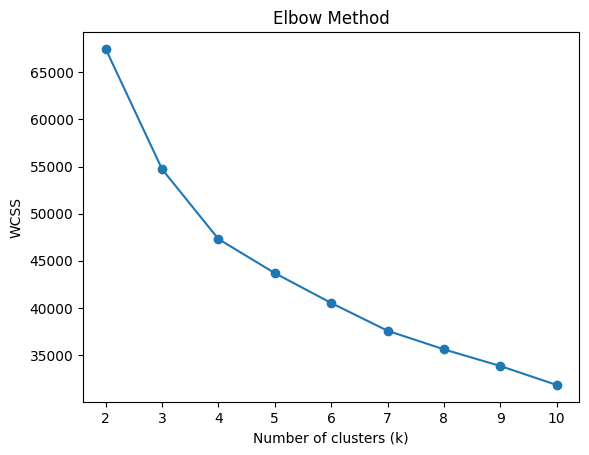

In [17]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(2, 11), wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

## 6. Train final KMeans model

Pick k based on the elbow chart above (using k=4 here — change if your elbow point differs).

In [18]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

df['cluster'] = labels
df['cluster'].value_counts()

cluster
1    4746
0    3618
3    1086
2     670
Name: count, dtype: int64

## 7. Save encoder, scaler, and KMeans model as pickle files

In [23]:
import pickle 
pickle.dump(encoder,open(r"C:\Users\ishik\FRAUD DETACTION\model\encoder.pkl","wb"))




In [24]:
pickle.dump(scaler,open(r"C:\Users\ishik\FRAUD DETACTION\model\scaler.pkl","wb"))

In [25]:
pickle.dump(kmeans,open(r"C:\Users\ishik\FRAUD DETACTION\model\kmeans.pkl","wb"))